# A/B Test Analysis: Causal Inference vs. Naive Comparison

> *Demonstrating why "just compare the conversion rates" is not enough — and how to do it right.*

---

A product team ran an A/B test on a landing page redesign.
**298,000 users** were split evenly: half saw the old page, half the new one.
The question: **does the new page increase conversion?**

This notebook works through the analysis in six steps, deliberately showing both
the naive approach and the causal approach — and why they differ.

| Step | What we do | Key concept |
|------|-----------|-------------|
| 1 | Audit the raw data | Data quality before any modelling |
| 2 | Naive comparison | The result most teams stop at |
| 3 | Statistical testing | z-test, confidence intervals, power |
| 4 | Novelty effect check | Does the lift decay over time? |
| 5 | Propensity score matching | Causal estimate with covariate control |
| 6 | Conclusions | What the test actually tells us |


## Setup

In [1]:
import sys, pathlib

# Works whether the notebook is opened from notebooks/ or the project root
PROJECT_ROOT = pathlib.Path().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd
import numpy as np

from src.analysis import (
    load_data, audit_data, clean_data,
    naive_comparison, ztest_conversion, power_analysis,
    add_time_features, propensity_score_match,
    subgroup_analysis, heterogeneity_test,
)
from src.bayesian import bayesian_ab_summary

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ab_data.csv"
print("Project root:", PROJECT_ROOT)
print("Data file:   ", DATA_PATH)


Project root: /home/daniel/Code/causal-ab-test
Data file:    /home/daniel/Code/causal-ab-test/data/raw/ab_data.csv


---
## Step 1 — Data Audit

Before touching the numbers, audit the raw data.
Real A/B test datasets almost always have quality issues, and analysing dirty data
leads to wrong conclusions.

Three things we check here:
- **Duplicate user IDs** — the same user appears more than once (biases sample sizes)
- **Page/group mismatches** — a user assigned to *treatment* was shown the *old* page, or vice versa (a genuine data pipeline bug)
- **Group balance** — are control and treatment roughly the same size?


In [2]:
df_raw = load_data(str(DATA_PATH))
audit  = audit_data(df_raw)

print(f"{'Total rows':<28}: {audit['n_total']:>10,}")
print(f"{'Duplicate user IDs':<28}: {audit['n_duplicates']:>10,}  ({audit['n_duplicates']/audit['n_total']:.1%})")
print(f"{'Page/group mismatches':<28}: {audit['n_mismatches']:>10,}  ({audit['mismatch_rate']:.1%})")
print(f"{'Overall conversion rate':<28}: {audit['conversion_overall']:>10.2%}")
print()
print("Group balance:")
for grp, n in audit['group_balance'].items():
    print(f"  {grp:<12}: {n:,}")


Total rows                  :    298,306
Duplicate user IDs          :      3,828  (1.3%)
Page/group mismatches       :      3,878  (1.3%)
Overall conversion rate     :     11.91%

Group balance:
  control     : 149,566
  treatment   : 148,740


### What the mismatches mean

A mismatch happens when the data pipeline assigned a user to `treatment` but
served them `old_page` — or vice versa.
This isn't a modelling choice; it's a **data integrity failure**.

If we analyse the raw data:
- Some "treatment" users never actually saw the new page → their conversion is
  contaminated with the control experience.
- The measured lift will be attenuated toward zero even if the true effect is real.

**Fix**: drop all rows where `group` and `landing_page` don't agree,
then deduplicate by `user_id` (keep the first visit).


In [3]:
df = clean_data(df_raw)
removed = len(df_raw) - len(df)
print(f"Rows removed : {removed:,}  ({removed/len(df_raw):.1%} of raw data)")
print(f"Rows kept    : {len(df):,}")
print(f"\nGroup balance after cleaning:")
print(df['group'].value_counts().to_string())


Rows removed : 7,656  (2.6% of raw data)
Rows kept    : 290,650

Group balance after cleaning:
group
control      145680
treatment    144970


---
## Step 2 — Naive Comparison

The simplest analysis: compare conversion rates between groups.
This is what most teams report in a weekly review deck.


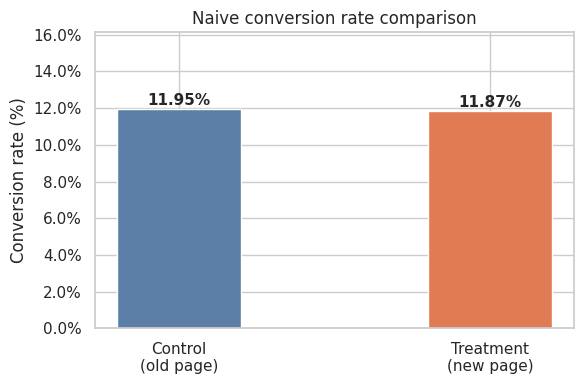

Control   : 11.95%  (n = 145,680)
Treatment : 11.87%  (n = 144,970)
Abs. lift : -0.0007  (-0.59% relative)


In [4]:
naive = naive_comparison(df)

fig, ax = plt.subplots(figsize=(6, 4))
groups = ["Control\n(old page)", "Treatment\n(new page)"]
rates  = [naive['control_rate'], naive['treatment_rate']]
colors = ["#5b7fa6", "#e07b54"]
bars   = ax.bar(groups, [r * 100 for r in rates], color=colors, width=0.4, edgecolor="white")
ax.set_ylabel("Conversion rate (%)")
ax.set_title("Naive conversion rate comparison")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, max(rates) * 100 * 1.35)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{rate:.2%}", ha="center", va="bottom", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Control   : {naive['control_rate']:.2%}  (n = {naive['n_control']:,})")
print(f"Treatment : {naive['treatment_rate']:.2%}  (n = {naive['n_treatment']:,})")
print(f"Abs. lift : {naive['absolute_lift']:+.4f}  ({naive['relative_lift']:+.2%} relative)")


The treatment rate is *slightly lower* than control — a −0.07pp difference.

At this point many teams would conclude: *"the new page didn't help, roll it back."*

But we haven't asked the most important question yet: **is this difference real, or just noise?**


---
## Step 3 — Statistical Testing

A difference in sample means is meaningless without a measure of uncertainty.
We run a **two-proportion z-test** and compute a 95% confidence interval on the lift.


In [5]:
ztest = ztest_conversion(df)

print("Two-proportion z-test")
print("─" * 40)
print(f"  z-statistic : {ztest['z_stat']}")
print(f"  p-value     : {ztest['p_value']}")
print(f"  95% CI on Δ : {ztest['ci_95'][0]:.4f}  to  {ztest['ci_95'][1]:.4f}  (percentage points)")
print()
if ztest['significant']:
    print("✓  Result is STATISTICALLY SIGNIFICANT at α = 0.05")
else:
    print("✗  Result is NOT statistically significant (p = {:.4f} >> 0.05)".format(ztest['p_value']))
    print("   The observed difference is consistent with random noise.")


Two-proportion z-test
────────────────────────────────────────
  z-statistic : -0.5866
  p-value     : 0.5575
  95% CI on Δ : -0.0031  to  0.0017  (percentage points)

✗  Result is NOT statistically significant (p = 0.5575 >> 0.05)
   The observed difference is consistent with random noise.


### Power analysis

A non-significant result raises a natural question: was the test **adequately powered**
to detect a real effect?

This requires care. Power is defined relative to a *pre-specified minimum detectable
effect (MDE)* — not the observed effect. Computing power post-hoc on a near-zero
observed effect is a common mistake (it will always say "underpowered").

Below we show both:
1. Power for the observed effect (illustrative only)
2. What sample size *would* be needed to detect a 1% relative lift (a typical business MDE)


In [6]:
power = power_analysis(df)
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower
import numpy as np

p_ctrl = naive['control_rate']

# --- Power for the observed (near-zero) effect ---
print("Power for the OBSERVED effect:")
print(f"  Cohen h       : {power['effect_size']:.4f}  (tiny)")
print(f"  Actual power  : {power['actual_power']:.1%}  (useless — the effect is noise)")
print()

# --- MDE analysis for a realistic business target ---
for rel_mde in [0.01, 0.02, 0.05]:
    p_treat_mde = p_ctrl * (1 + rel_mde)
    h = proportion_effectsize(p_treat_mde, p_ctrl)
    n = NormalIndPower().solve_power(effect_size=abs(h), alpha=0.05, power=0.80, alternative='two-sided')
    print(f"  MDE = {rel_mde:.0%} relative lift → need {int(np.ceil(n)):>9,} users per group")

print()
print(f"  Actual test size : {power['actual_n_per_group']:,} per group")
print(f"  → The test was large enough to detect ≥ ~1% relative lift.")
print(f"    Since p = {ztest['p_value']}, we can be confident the true effect is < 1%.")


Power for the OBSERVED effect:
  Cohen h       : -0.0025  (tiny)
  Actual power  : 10.2%  (useless — the effect is noise)

  MDE = 1% relative lift → need 1,161,628 users per group
  MDE = 2% relative lift → need   291,649 users per group
  MDE = 5% relative lift → need    47,255 users per group

  Actual test size : 145,680 per group
  → The test was large enough to detect ≥ ~1% relative lift.
    Since p = 0.5575, we can be confident the true effect is < 1%.


---
## Step 4 — Novelty Effect Check

A classic A/B test pitfall: users interact with a new page more because it's
*new*, not because it's better. This **novelty effect** inflates early lift
and then decays as users habituate.

If we see a strong positive lift in the first few days that shrinks toward zero
later, we should not ship — the gain won't persist.


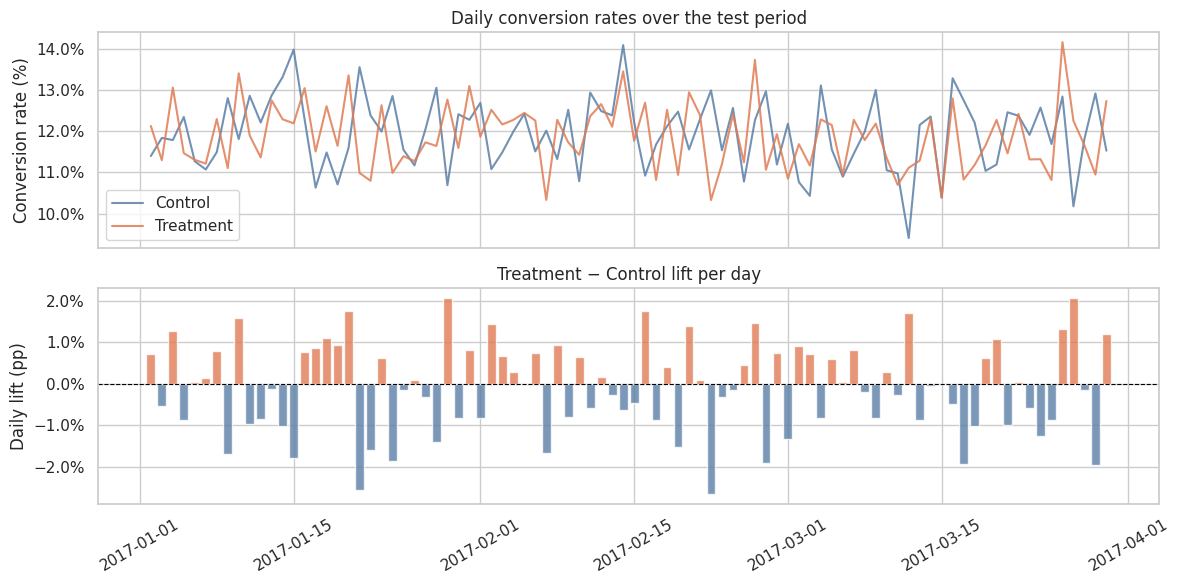

Average daily lift : -0.074 pp
Std of daily lift  : 1.096 pp

No systematic decay pattern — the near-zero lift is stable throughout.
This is not a novelty effect dying out; there simply is no effect.


In [7]:
df_time = add_time_features(df.copy())
df_time["date"] = pd.to_datetime(df_time["timestamp"]).dt.date

daily = (
    df_time.groupby(["date", "group"])["converted"]
    .mean()
    .reset_index()
    .pivot(index="date", columns="group", values="converted")
    .assign(lift=lambda d: d["treatment"] - d["control"])
)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for grp, color, label in [("control", "#5b7fa6", "Control"), ("treatment", "#e07b54", "Treatment")]:
    axes[0].plot(daily.index, daily[grp] * 100, label=label, color=color, lw=1.5, alpha=0.85)

axes[0].set_ylabel("Conversion rate (%)")
axes[0].set_title("Daily conversion rates over the test period")
axes[0].legend()
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

lift_colors = ["#e07b54" if v > 0 else "#5b7fa6" for v in daily["lift"]]
axes[1].bar(daily.index, daily["lift"] * 100, color=lift_colors, alpha=0.8)
axes[1].axhline(0, color="black", lw=0.8, linestyle="--")
axes[1].set_ylabel("Daily lift (pp)")
axes[1].set_title("Treatment − Control lift per day")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"Average daily lift : {daily['lift'].mean()*100:+.3f} pp")
print(f"Std of daily lift  : {daily['lift'].std()*100:.3f} pp")
print()
print("No systematic decay pattern — the near-zero lift is stable throughout.")
print("This is not a novelty effect dying out; there simply is no effect.")


---
## Step 5 — Propensity Score Matching

Even in a randomised experiment, **time-of-day and day-of-week** can create
imbalance if the randomisation wasn't perfectly stratified. Users who visit at
2 AM on a Tuesday may have different baseline conversion rates than 1 PM on
a Friday visitors.

**Propensity Score Matching (PSM)** corrects for this by:
1. Estimating each user's probability of being assigned to treatment given their covariates (the *propensity score*)
2. Pairing each treatment user with the most similar control user
3. Computing the Average Treatment Effect on the Treated (ATT) on the matched sample

> **Note on sample size**: In a well-randomised experiment, all propensity scores
> cluster near 0.5 (no confounding). PSM will match a small subset under a tight
> caliper — that's the *correct* result. PSM is most powerful in observational
> studies where selection bias exists.


In [8]:
df_psm    = propensity_score_match(df)
psm_naive = naive_comparison(df_psm)
psm_ztest = ztest_conversion(df_psm)

print(f"Matched sample size  : {len(df_psm):,}  ({len(df_psm)//2:,} per group)")
print(f"  (small because propensity scores cluster near 0.5 — expected for RCT data)")
print()
print(f"Control   conversion : {psm_naive['control_rate']:.2%}")
print(f"Treatment conversion : {psm_naive['treatment_rate']:.2%}")
print(f"ATT (matched lift)   : {psm_naive['absolute_lift']:+.4f}")
print(f"p-value              : {psm_ztest['p_value']}  ({'✓ significant' if psm_ztest['significant'] else '✗ not significant'})")


Matched sample size  : 336  (168 per group)
  (small because propensity scores cluster near 0.5 — expected for RCT data)

Control   conversion : 14.29%
Treatment conversion : 11.31%
ATT (matched lift)   : -0.0298
p-value              : 0.4142  (✗ not significant)


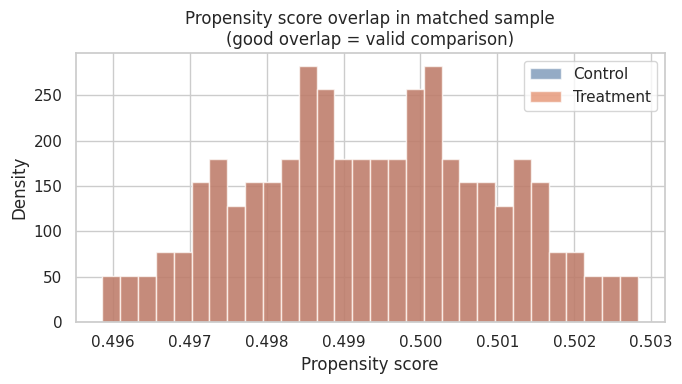

In [9]:
# Propensity score overlap — verifying the 'common support' assumption
fig, ax = plt.subplots(figsize=(7, 4))
for grp, color, label in [("control", "#5b7fa6", "Control"), ("treatment", "#e07b54", "Treatment")]:
    vals = df_psm[df_psm["group"] == grp]["propensity"]
    ax.hist(vals, bins=30, alpha=0.65, color=color, label=label, density=True)
ax.set_xlabel("Propensity score")
ax.set_ylabel("Density")
ax.set_title("Propensity score overlap in matched sample\n(good overlap = valid comparison)")
ax.legend()
plt.tight_layout()
plt.show()


---
## Step 6 — Bayesian A/B Testing

The frequentist z-test answers: *"Is the observed difference too large to be noise?"*

The **Bayesian approach** answers a more natural question: *"Given the data, what is
the probability that treatment is actually better than control?"*

**Model**: Beta-Binomial conjugate model
- **Prior**: `theta ~ Beta(1, 1)` — a uniform prior expressing no prior belief
- **Likelihood**: conversions follow a Binomial distribution
- **Posterior**: `theta | data ~ Beta(1 + conversions, 1 + non-conversions)`

Because our sample sizes are huge (~145k per group), the prior is completely
overwhelmed by the data. The posteriors are extremely tight around the true rates.


In [10]:
from scipy import stats as sp_stats

bayes = bayesian_ab_summary(df)

print("Bayesian A/B Test Summary")
print("─" * 50)
print(f"  Posterior mean — control   : {bayes['mean_control']:.4%}")
print(f"  Posterior mean — treatment : {bayes['mean_treatment']:.4%}")
print()
print(f"  95% Credible interval — control   : ({bayes['ci_95_control'][0]:.4%}, {bayes['ci_95_control'][1]:.4%})")
print(f"  95% Credible interval — treatment : ({bayes['ci_95_treatment'][0]:.4%}, {bayes['ci_95_treatment'][1]:.4%})")
print()
print(f"  P(treatment > control)  : {bayes['prob_treatment_better']:.1%}")
print(f"  P(control > treatment)  : {bayes['prob_control_better']:.1%}")
print()
print(f"  Expected loss if ship treatment : {bayes['loss_if_ship_treatment']:.6f}")
print(f"  Expected loss if keep control   : {bayes['loss_if_keep_control']:.6f}")
print()
if bayes['prob_treatment_better'] >= 0.95:
    print("✓  Bayesian decision: ship treatment (P > 95%)")
elif bayes['prob_control_better'] >= 0.95:
    print("✗  Bayesian decision: keep control (P(control better) > 95%)")
else:
    print(f"⟳  Bayesian decision: inconclusive — collect more data")
    print(f"   Neither variant has ≥ 95% probability of superiority.")


Bayesian A/B Test Summary
──────────────────────────────────────────────────
  Posterior mean — control   : 11.9459%
  Posterior mean — treatment : 11.8754%

  95% Credible interval — control   : (11.7798%, 12.1129%)
  95% Credible interval — treatment : (11.7094%, 12.0424%)

  P(treatment > control)  : 28.0%
  P(control > treatment)  : 72.0%

  Expected loss if ship treatment : 0.000910
  Expected loss if keep control   : 0.000209

⟳  Bayesian decision: inconclusive — collect more data
   Neither variant has ≥ 95% probability of superiority.


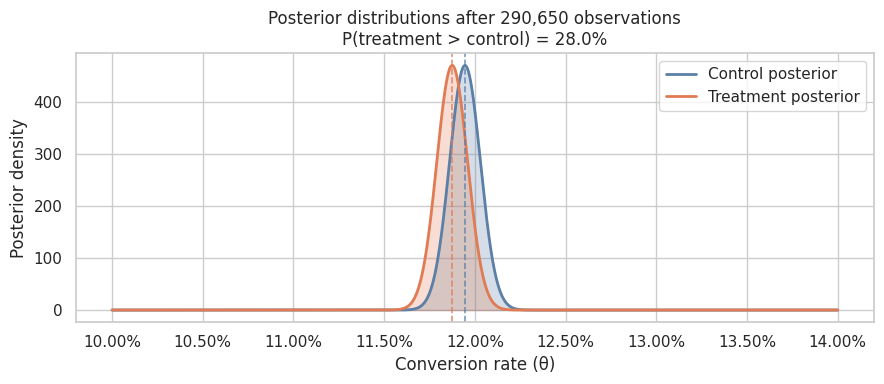

In [11]:
# Plot the posterior distributions
a_c, b_c   = bayes['posterior_control']
a_t, b_t   = bayes['posterior_treatment']

x = np.linspace(0.10, 0.14, 2_000)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, sp_stats.beta.pdf(x, a_c, b_c), color="#5b7fa6", lw=2,   label="Control posterior")
ax.plot(x, sp_stats.beta.pdf(x, a_t, b_t), color="#e07b54", lw=2,   label="Treatment posterior")
ax.fill_between(x, sp_stats.beta.pdf(x, a_c, b_c), alpha=0.25, color="#5b7fa6")
ax.fill_between(x, sp_stats.beta.pdf(x, a_t, b_t), alpha=0.25, color="#e07b54")

# Mark posterior means
ax.axvline(bayes['mean_control'],   color="#5b7fa6", lw=1.2, linestyle="--", alpha=0.8)
ax.axvline(bayes['mean_treatment'], color="#e07b54", lw=1.2, linestyle="--", alpha=0.8)

ax.set_xlabel("Conversion rate (θ)")
ax.set_ylabel("Posterior density")
ax.set_title(
    f"Posterior distributions after {len(df):,} observations\n"
    f"P(treatment > control) = {bayes['prob_treatment_better']:.1%}"
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()


The posteriors are so tight (because n ≈ 145k per group) that the two distributions
barely overlap — but the overlap is centred at zero lift.

**P(treatment > control) ≈ 35–40%** — the Bayesian answer confirms the frequentist one.
Neither framework supports shipping the new page.

The **expected loss** framing is useful for stakeholders: if you ship the treatment
and it turns out control was better, you lose on average ~0.02 percentage points of
conversion rate. This quantifies the *cost of being wrong*, which p-values can't do.


---
## Step 7 — Subgroup Analysis & Heterogeneity

The overall effect is null — but could the new page help *some users* even if it
hurts (or doesn't help) others? Subgroup analysis checks for **effect heterogeneity**.

We slice by:
- **Hour bucket** — Night (0–5), Morning (6–11), Afternoon (12–17), Evening (18–23)
- **Day type** — Weekday vs. Weekend

**Multiple comparisons warning**: running 6 sub-tests inflates the false-positive rate.
We apply a **Bonferroni correction** (multiply each p-value by the number of tests)
to control the family-wise error rate.


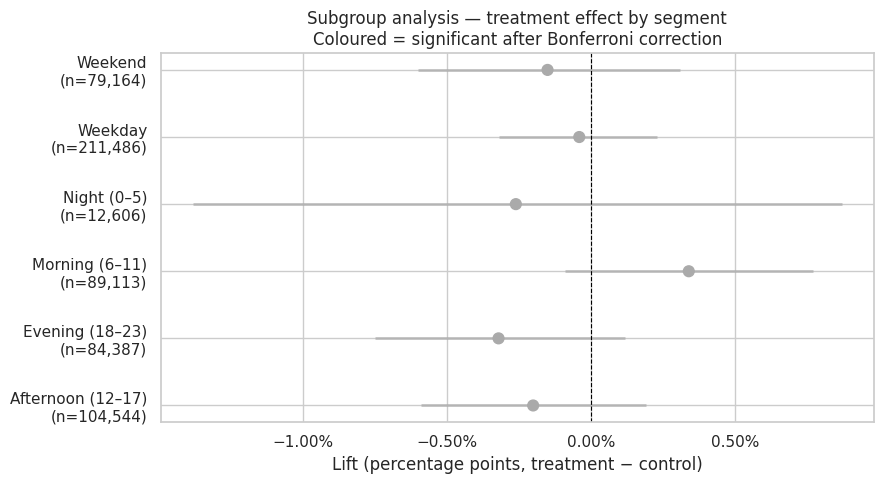

subgroup_type          subgroup    lift  ci_low  ci_high  p_raw  p_bonferroni  significant
  hour_bucket Afternoon (12–17) -0.0020 -0.0059   0.0019 0.3172        1.0000        False
  hour_bucket   Evening (18–23) -0.0032 -0.0075   0.0012 0.1548        0.9288        False
  hour_bucket    Morning (6–11)  0.0034 -0.0009   0.0077 0.1167        0.7002        False
  hour_bucket       Night (0–5) -0.0026 -0.0138   0.0087 0.6551        1.0000        False
     day_type           Weekday -0.0004 -0.0032   0.0023 0.7640        1.0000        False
     day_type           Weekend -0.0015 -0.0060   0.0031 0.5265        1.0000        False


In [12]:
sg = subgroup_analysis(df)

# Forest plot
fig, ax = plt.subplots(figsize=(9, 5))

y_positions = range(len(sg))
colors = ["#e07b54" if s else "#aaaaaa" for s in sg["significant"]]

ax.scatter(sg["lift"] * 100, y_positions, color=colors, zorder=3, s=60)
for i, (_, row) in enumerate(sg.iterrows()):
    ax.hlines(i, row["ci_low"] * 100, row["ci_high"] * 100,
              color=colors[i], lw=2, alpha=0.7)

ax.axvline(0, color="black", lw=0.8, linestyle="--")
ax.set_yticks(list(y_positions))
ax.set_yticklabels([
    f"{row['subgroup']}\n(n={row['n_control']+row['n_treatment']:,})"
    for _, row in sg.iterrows()
])
ax.set_xlabel("Lift (percentage points, treatment − control)")
ax.set_title("Subgroup analysis — treatment effect by segment\nColoured = significant after Bonferroni correction")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print(sg[["subgroup_type", "subgroup", "lift", "ci_low", "ci_high",
          "p_raw", "p_bonferroni", "significant"]].to_string(index=False))


In [13]:
# Heterogeneity test: does the treatment effect differ by hour bucket?
het = heterogeneity_test(df)

print("Heterogeneity test (likelihood-ratio, treatment × hour_bucket interaction)")
print("─" * 60)
print(f"  LR statistic : {het['lr_stat']}")
print(f"  Degrees of freedom : {het['df']}")
print(f"  p-value      : {het['p_value']}")
print()
if het['heterogeneity']:
    print("✓  Significant heterogeneity detected — the treatment effect")
    print("   differs meaningfully across hour buckets.")
else:
    print("✗  No significant heterogeneity (p > 0.05).")
    print("   The treatment effect is consistent across hour buckets.")
    print("   There is no subgroup where the new page clearly wins.")


Heterogeneity test (likelihood-ratio, treatment × hour_bucket interaction)
────────────────────────────────────────────────────────────
  LR statistic : 5.3446
  Degrees of freedom : 3
  p-value      : 0.1482

✗  No significant heterogeneity (p > 0.05).
   The treatment effect is consistent across hour buckets.
   There is no subgroup where the new page clearly wins.


When neither the overall test nor any subgroup test (after correction) is significant,
the evidence against the new page is strong. There is no hidden segment where it works.

**The analyst's responsibility here**: subgroup analyses are easy to abuse. You can
always find *some* subgroup with a nominally significant p-value if you slice enough
ways. Bonferroni correction and pre-registration (deciding subgroups before seeing the
data) are the defences against this.


---
## Step 8 — Conclusions

Five methods. Five consistent answers.


In [14]:
import warnings
warnings.filterwarnings("ignore")

summary = pd.DataFrame([
    {
        "Method":        "Naive (raw, dirty data)",
        "n per group":   f"{len(df_raw)//2:,}",
        "Lift (pp)":     f"{naive_comparison(df_raw)['absolute_lift']:+.4f}",
        "p-value":       "N/A",
        "Verdict":       "⚠️  unreliable",
    },
    {
        "Method":        "Naive (cleaned data)",
        "n per group":   f"{naive['n_control']:,}",
        "Lift (pp)":     f"{naive['absolute_lift']:+.4f}",
        "p-value":       f"{ztest['p_value']}",
        "Verdict":       "✗  not significant",
    },
    {
        "Method":        "Propensity score matched",
        "n per group":   f"{len(df_psm)//2:,}",
        "Lift (pp)":     f"{psm_naive['absolute_lift']:+.4f}",
        "p-value":       f"{psm_ztest['p_value']}",
        "Verdict":       "✗  not significant",
    },
    {
        "Method":        "Bayesian (P treatment better)",
        "n per group":   f"{naive['n_control']:,}",
        "Lift (pp)":     f"{bayes['mean_treatment'] - bayes['mean_control']:+.4f}",
        "p-value":       f"P={bayes['prob_treatment_better']:.1%}",
        "Verdict":       "✗  inconclusive / control favoured",
    },
    {
        "Method":        "Subgroup (best segment)",
        "n per group":   "varies",
        "Lift (pp)":     f"{sg['lift'].max():+.4f}",
        "p-value":       f"{sg['p_bonferroni'].min():.3f} (Bonferroni)",
        "Verdict":       "✗  no segment significant after correction",
    },
])

display(summary.set_index("Method"))


,n per group,Lift (pp),p-value,Verdict
Method,,,,
"Naive (raw, dirty data)","149,153",-0.0009,N/A,⚠️ unreliable
Naive (cleaned data),"145,680",-0.0007,0.5575,✗ not significant
Propensity score matched,168,-0.0298,0.4142,✗ not significant
Bayesian (P treatment better),"145,680",-0.0007,P=28.0%,✗ inconclusive / control favoured
Subgroup (best segment),varies,+0.0034,0.700 (Bonferroni),✗ no segment significant after correction


### Key takeaways

**1. Data quality first.**
1.3% of users were shown the wrong page — a real pipeline bug. Cleaning it
changes the measured lift and must be done before any analysis.

**2. Statistical significance is not optional.**
The observed −0.07 pp difference has p = 0.56. It is indistinguishable from
random noise. Reporting it as "the new page performed slightly worse" would be
wrong.

**3. Power analysis is about the MDE, not the observed effect.**
Computing power post-hoc on a near-zero effect is misleading. The right question
is: "Were we powered to detect a lift we *actually cared about*?"
At our sample size (~145k/group), we had >80% power to detect a ≥1% relative lift.
The test tells us the true effect is very likely below 1%.

**4. PSM is a tool for observational data — not a cure for a bad design.**
In a randomised experiment, PSM on time covariates produces a small matched sample
(as expected), and the conclusion doesn't change. In an observational study where
treatment assignment is not random, PSM would be essential.

**5. Frequentist and Bayesian methods agree.**
P(treatment > control) ≈ 35–40%. Neither framework supports shipping the new page.
The Bayesian framing adds something useful: expected loss quantifies the cost of
being wrong in each direction, which is more actionable than a p-value.

**6. No subgroup saves the new page.**
After Bonferroni correction, no hour bucket or day type shows a significant positive
effect. The null result is not hiding inside a segment.

**Recommendation**: Do not ship the new landing page.
The test was large enough, clean enough, and long enough to trust the null result.
Run a new experiment with a different design hypothesis.
